# **CV ASSIGNMENT**
**Name:** Varsha Shivanand K

**USN:** 1RUA24CSE0516

B.Tech 5th Semester - Section F

# **1) High-Boost Filtering**

Implement a system that enhances high-frequency components while retaining part of the original image:

$$
f_{hb} = (A - 1)f_{orig} + f_{sharpened}
$$

Importing OpenCV for image operations, NumPy for math and array handling and Matplotlib for displaying images and plots.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Loading the image in grayscale mode.



In [2]:
img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found. Check the file name.")

print("Image shape:", img.shape)
print("Minimum intensity:", img.min())
print("Maximum intensity:", img.max())

Image shape: (5184, 3456)
Minimum intensity: 0
Maximum intensity: 255


Displays the original image before any processing.

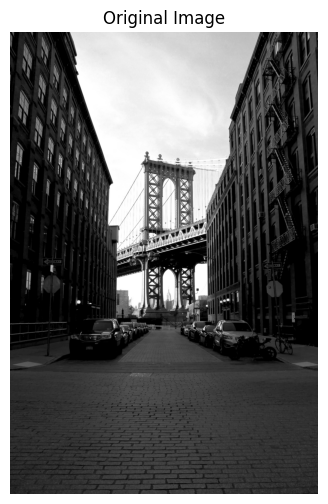

In [3]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

Here we convert the image from the spatial domain to the frequency domain using the 2D Fast Fourier Transform (fft2). Every image can be described as a sum of sine and cosine waves of different frequencies. This step finds those frequency components. fftshift then moves the zero-frequency (average brightness) component from the corner of the array to the center.

In [4]:
img_float = np.float32(img)

F = np.fft.fft2(img_float)

F_shift = np.fft.fftshift(F)

print("Spatial domain shape:", img_float.shape)
print("Frequency domain shape:", F_shift.shape)

Spatial domain shape: (5184, 3456)
Frequency domain shape: (5184, 3456)


This shows the magnitude spectrum, which is a visual representation of how much energy exists at each frequency. Bright areas near the center represent low frequencies (smooth regions of the image), and areas farther represent high frequencies (edges and fine detail). We take the log because raw magnitude values vary too widely to see clearly otherwise.

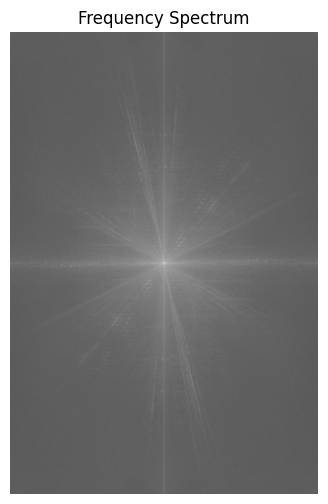

In [5]:
magnitude_spectrum = np.log(1 + np.abs(F_shift))

plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Frequency Spectrum")
plt.axis("off")
plt.show()

Building a circular mask to act as a high-pass filter. Pixels within a small radius of the center (low frequencies) are set to 0, and everything outside that radius (high frequencies) stays at 1. Multiplying the frequency data by this mask will remove the low-frequency information and keep only the high-frequency detail.

In [6]:
rows, cols = img.shape

crow, ccol = rows // 2, cols // 2

mask = np.ones((rows, cols), np.float32)

radius = 30

y, x = np.ogrid[:rows, :cols]

distance = np.sqrt((x - ccol)**2 + (y - crow)**2)

mask[distance <= radius] = 0

Applying the high-pass mask to the frequency domain image. This removes the low-frequency components (smooth areas, overall brightness) and keeps only the high-frequency ones (edges, fine detail, noise).

In [7]:
F_high = F_shift * mask

Now converting the filtered result back to the spatial domain. ifftshift undoes the earlier shift, and ifft2 performs the inverse Fourier Transform. Only the real part of the result is taken because small imaginary components can appear due to floating-point rounding, and only the real part is the actual pixel values.

In [8]:
F_ishift = np.fft.ifftshift(F_high)

high_freq = np.fft.ifft2(F_ishift)

high_freq = np.real(high_freq)

print("High-frequency image generated.")

High-frequency image generated.


Normalize the high-frequency result to the 0-255 range so it can be displayed and treated as a normal image, then visualize it. This image will mostly show edges and fine detail, since the smooth low-frequency parts were removed.

In [9]:
high_freq_norm = cv2.normalize(
    high_freq,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

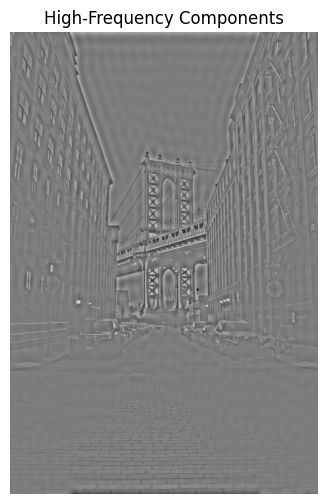

In [10]:
plt.figure(figsize=(6, 6))
plt.imshow(high_freq_norm, cmap='gray')
plt.title("High-Frequency Components")
plt.axis("off")
plt.show()

This is the High-Boost Filtering step. Here we combine the original image with the high-frequency detail using the formula fhb = (A-1) * forig + fsharpened, where A controls how strongly the high-frequency detail is boosted. A higher A value makes edges and fine details stand out more while still keeping the overall image recognizable.

In [11]:
A = 1.5

original_float = img.astype(np.float32)

f_sharpened = original_float + high_freq
high_boost = (A - 1) * original_float + f_sharpened

high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)

This compares the original image with the high-boost filtered result side by side, so we can see the sharpening effect.

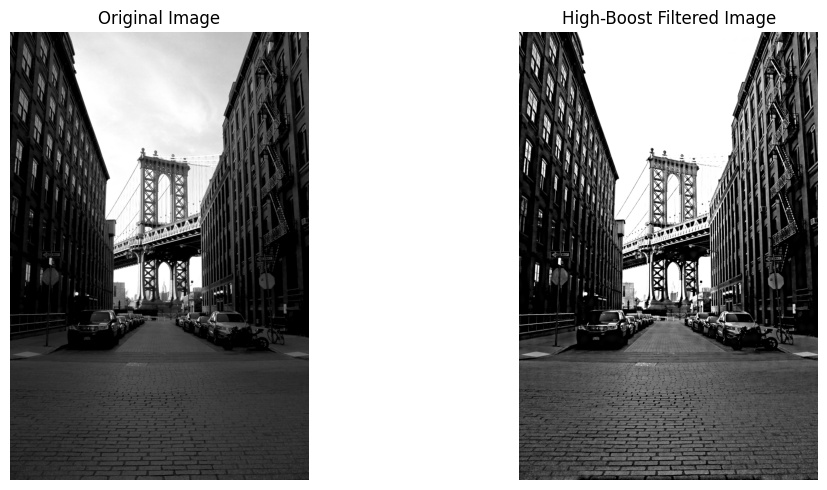

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_boost, cmap='gray')
plt.title("High-Boost Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

At A = 1, the result is the sharpened image. As A increases, the sharpening effect becomes stronger. Very high A values may cause over-bright or saturated regions.

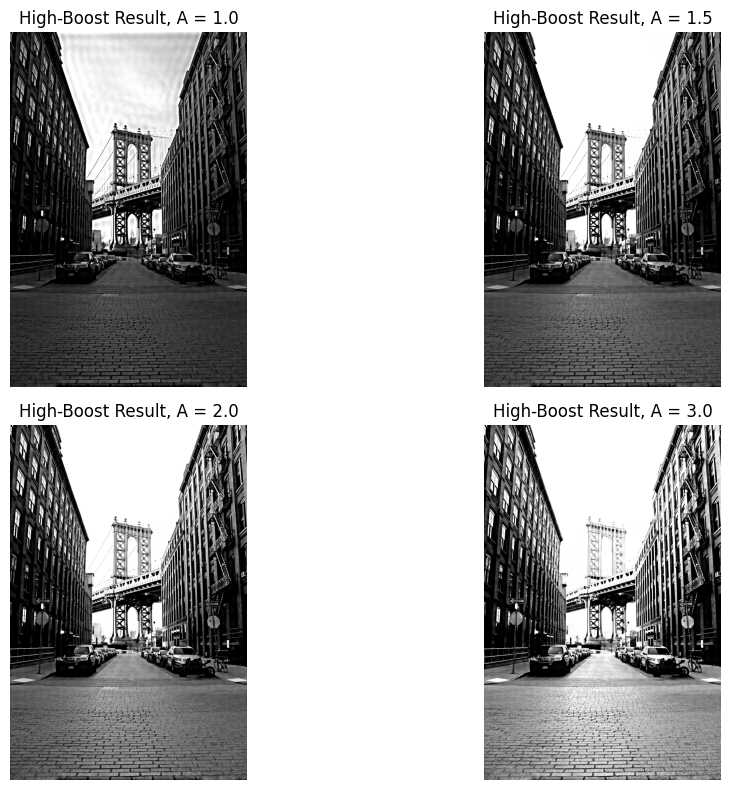

In [13]:
boost_values = [1.0, 1.5, 2.0, 3.0]

plt.figure(figsize=(12, 8))

for i, A in enumerate(boost_values):
    result = (A - 1) * original_float + f_sharpened

    result = np.clip(result, 0, 255).astype(np.uint8)

    plt.subplot(2, 2, i + 1)
    plt.imshow(result, cmap='gray')
    plt.title(f"High-Boost Result, A = {A}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#**2) Adaptive Local Enhancement**
Write a script that applies **Gamma correction locally**, using different $\gamma$ values for **dark and bright sub-regions** of an image.

We convert the image to a 0-1 float range and calculate its overall mean intensity. This value will be used as a reference to decide whether a region of the image counts as dark or bright.

In [14]:
img_float = img.astype(np.float32) / 255.0

mean_intensity = np.mean(img_float)

print("Mean intensity:", mean_intensity)

Mean intensity: 0.3099523


This is the Adaptive Local Enhancement step. Instead of applying one gamma correction value to the whole image, we divide the image into small blocks (32x32 pixels here). For each block, we find its local mean brightness and compare it to the image's overall mean. If the block is darker than average, we apply a lower gamma (which brightens it), and if it's brighter than average, we apply a higher gamma (which darkens it slightly). So different parts of the image get corrected differently based on their local brightness.

In [15]:
block_size = 32
h, w = img_float.shape
adaptive_gamma = np.zeros_like(img_float)

gamma_dark = 0.5
gamma_bright = 1.5

for y in range(0, h, block_size):
    for x in range(0, w, block_size):
        block = img_float[y:y+block_size, x:x+block_size]
        local_mean = np.mean(block)

        if local_mean < mean_intensity:   # dark local region
            gamma_val = gamma_dark
        else:                              # bright local region
            gamma_val = gamma_bright

        adaptive_gamma[y:y+block_size, x:x+block_size] = block ** gamma_val

adaptive_gamma = np.clip(adaptive_gamma * 255, 0, 255).astype(np.uint8)

This is a smoother version. Instead of changing gamma values abruptly at block boundaries, we compute a local mean for every pixel using a box blur, then the gamma value changes gradually and continuously across the image based on that local brightness. This avoids the visible blocky edges that the block-wise version can produce.

In [16]:
local_mean_map = cv2.blur(img_float, (block_size, block_size))

gamma_map = gamma_dark + (gamma_bright - gamma_dark) * (
    (local_mean_map - local_mean_map.min()) /
    (local_mean_map.max() - local_mean_map.min())
)

adaptive_gamma_smooth = np.clip((img_float ** gamma_map) * 255, 0, 255).astype(np.uint8)

Comparing four versions side by side: the original image, a simple global gamma correction (same gamma applied everywhere), the block-wise adaptive version and the smooth adaptive version. Here we see how local processing differs from a single global correction.

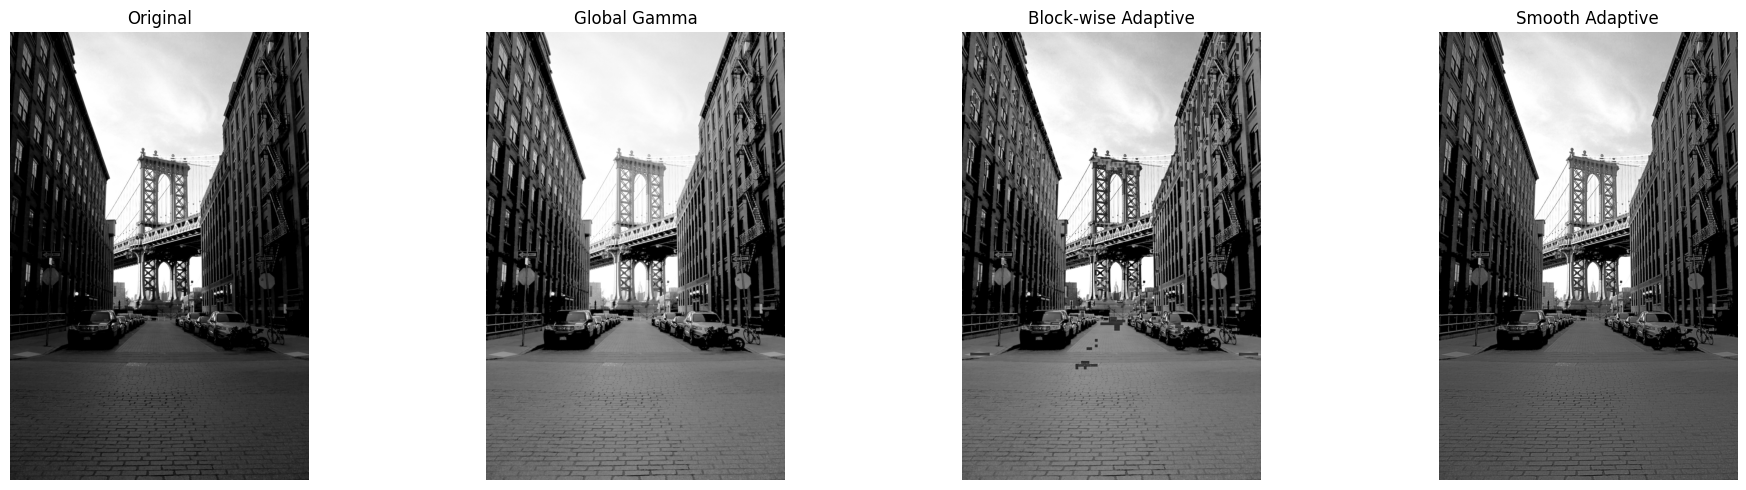

In [17]:
gamma = 0.5

global_gamma = (
    255 * (img_float ** gamma)
).astype(np.uint8)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(global_gamma, cmap='gray')
plt.title("Global Gamma")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(adaptive_gamma, cmap='gray')
plt.title("Block-wise Adaptive")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(adaptive_gamma_smooth, cmap='gray')
plt.title("Smooth Adaptive")
plt.axis("off")

plt.tight_layout()
plt.show()